In [1]:
import cv2
import os
import re
import h5py
import keras
import random
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt
from keras.models import Sequential, Model
from sklearn.model_selection import train_test_split
from keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report,confusion_matrix
from keras.layers import Dense, Conv2D , MaxPool2D , Flatten , Dropout , MaxPooling2D
from keras.applications import VGG19, ResNet50, NASNetLarge, DenseNet201, VGG16, InceptionResNetV2, Xception, ResNet152, InceptionV3, DenseNet121

In [2]:
IMG_SIZE = 224
CLASSES  = 0
LABELS   = []
FLOATX_R = r'default' #float16, float32, float64(default)
LAB_PATH = r'../input/solution12/224x224float64_Labels.npy'
TRA_PATH = r'../input/solution12/224x224float64_Train.h5'
VAL_PATH = r'../input/solution12/224x224float64_Val.h5'
BATCH_SI = 64 #48
EPOCHS   = 64 #86

In [3]:
#Set floatx for backend
print(r'======= SET FLOATX FOR BACKEND')
if FLOATX_R != r'default' and FLOATX_R != r'float64':
    keras.backend.set_floatx(FLOATX_R)
    keras.backend.set_epsilon(1e-4) #default is 1e-7
else:
    FLOATX_R = r'float64'
print(r'Set floatx : ', FLOATX_R)
print(r'Done')

======= SET FLOATX FOR BACKEND
Set floatx :  float64
Done


In [4]:
#Load data train
print(r'======= LOAD LABELS')
LABELS = np.load(LAB_PATH)
print(r'Done')
print(r'======= SET NO OF CLASSES')
CLASSES = len(LABELS)
print(r'No of classes : ', CLASSES)
print(LABELS)
print(r'Done')

======= LOAD LABELS
Done
======= SET NO OF CLASSES
No of classes :  5
['ArtDecor' 'Hitech' 'Indochina' 'Industrial' 'Scandinavian']
Done


In [5]:
#Load data train
print(r'======= LOAD DATA TRAIN')
hf = h5py.File(TRA_PATH, 'r')
print(r'All key in data train : ' , hf.keys())
x_train = np.array(hf.get('x'), dtype=FLOATX_R)
y_train = np.array(hf.get('y'), dtype=FLOATX_R)
hf.close()
del hf
print(r'Shape : ',x_train.shape, y_train.shape)
print(r'Done')

======= LOAD DATA TRAIN
All key in data train :  <KeysViewHDF5 ['x', 'y']>
Shape :  (3056, 224, 224, 3) (3056,)
Done


In [6]:
#Load data test/val
print(r'======= LOAD DATA TEST/VAL')
hf = h5py.File(VAL_PATH, 'r')
print(r'All key in data test/val : ' , hf.keys())
x_test = np.array(hf.get('x'))
y_test = np.array(hf.get('y'))
hf.close()
del hf
print(r'Shape : ',x_test.shape, y_test.shape)
print(r'Done')

======= LOAD DATA TEST/VAL
All key in data test/val :  <KeysViewHDF5 ['x', 'y']>
Shape :  (770, 224, 224, 3) (770,)
Done


In [7]:
#Convert multi-class labels to binary labels
print(r'======= CONVERT LABELS TO BINARY LABELS')
from sklearn.preprocessing import LabelBinarizer
label_binarizer = LabelBinarizer()
print('Shape All : ',x_train.shape, y_train.shape, x_test.shape, y_test.shape)
y_test = label_binarizer.fit_transform(y_test)
y_train = label_binarizer.fit_transform(y_train)
print('Shape All : ',x_train.shape, y_train.shape, x_test.shape, y_test.shape)
print(r'Done')

======= CONVERT LABELS TO BINARY LABELS
Shape All :  (3056, 224, 224, 3) (3056,) (770, 224, 224, 3) (770,)
Shape All :  (3056, 224, 224, 3) (3056, 5) (770, 224, 224, 3) (770, 5)
Done


In [8]:
# Detect hardware, return appropriate distribution strategy
try:
    # TPU detection. No parameters necessary if TPU_NAME environment variable is
    # set: this is always the case on Kaggle.
    tpu = tf.distribute.cluster_resolver.TPUClusterResolver()
    print('Running on TPU ', tpu.master())
except ValueError:
    tpu = None

if tpu:
    tf.config.experimental_connect_to_cluster(tpu)
    tf.tpu.experimental.initialize_tpu_system(tpu)
    strategy = tf.distribute.experimental.TPUStrategy(tpu)
else:
    # Default distribution strategy in Tensorflow. Works on CPU and single GPU.
    strategy = tf.distribute.get_strategy()

print("REPLICAS: ", strategy.num_replicas_in_sync)

Running on TPU  grpc://10.0.0.2:8470
REPLICAS:  8


In [9]:
#Create function learning rate reduction
print(r'======= CREATE MODEL PRETRAIN')
with strategy.scope():
    pre_trained_model = DenseNet201(input_shape=(IMG_SIZE, IMG_SIZE, 3),include_top=False, weights="imagenet")

#     for layer in pre_trained_model.layers:
#         layer.trainable = False

    
#     model = Sequential([
#         pre_trained_model,
#         #MaxPool2D((2,2) , strides = 2),
#         Flatten(),
#         Dense(1024, activation='relu'),
#         Dropout(0.5),
#         Dense(CLASSES , activation='softmax')])

    model = Sequential([
        pre_trained_model,
        MaxPool2D((2,2) , strides = 2),
        Flatten(),
        Dense(CLASSES , activation='softmax')])
#         Dense(CLASSES , activation='sigmoid')])

    model.compile(optimizer = "adam" , loss = 'categorical_crossentropy' , metrics = ['accuracy'])
#     model.compile(optimizer = "adam" , loss = 'binary_crossentropy' , metrics = ['accuracy'])
model.summary()
print(r'Done')

======= CREATE MODEL PRETRAIN
74842112/74836368 [==============================] - 3s 0us/step
Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
densenet201 (Model)          (None, 7, 7, 1920)        18321984  
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 3, 3, 1920)        0         
_________________________________________________________________
flatten (Flatten)            (None, 17280)             0         
_________________________________________________________________
dense (Dense)                (None, 5)                 86405     
Total params: 18,408,389
Trainable params: 18,179,333
Non-trainable params: 229,056
_________________________________________________________________
Done


In [10]:
#Create function learning rate reduction
print(r'======= CREATE FUNCTION LEARNING RATE REDUCTION')
from keras.callbacks import ReduceLROnPlateau
learning_rate_reduction = ReduceLROnPlateau(monitor='val_accuracy', patience = 2, verbose=1,factor=0.3, min_lr=0.000001)
print(r'Done')

======= CREATE FUNCTION LEARNING RATE REDUCTION
Done


In [11]:
#Fit model
print(r'======= FIT MODEL')
history = model.fit(x_train,y_train, batch_size = BATCH_SI , epochs = EPOCHS , validation_data = (x_test, y_test),callbacks = [learning_rate_reduction])
print(r'Done')

======= FIT MODEL
Epoch 1/64
48/48 [==============================] - 125s 3s/step - accuracy: 0.5746 - loss: 1.7570 - val_accuracy: 0.1857 - val_loss: 36814.9766 - lr: 0.0010
Epoch 2/64
48/48 [==============================] - 11s 222ms/step - accuracy: 0.7219 - loss: 0.8375 - val_accuracy: 0.3468 - val_loss: 18.1201 - lr: 0.0010
Epoch 3/64
48/48 [==============================] - 11s 228ms/step - accuracy: 0.8020 - loss: 0.5937 - val_accuracy: 0.4065 - val_loss: 4.6199 - lr: 0.0010
Epoch 4/64
48/48 [==============================] - 11s 227ms/step - accuracy: 0.8393 - loss: 0.4608 - val_accuracy: 0.7416 - val_loss: 1.0293 - lr: 0.0010
Epoch 5/64
48/48 [==============================] - 11s 230ms/step - accuracy: 0.8655 - loss: 0.3942 - val_accuracy: 0.6013 - val_loss: 1.9258 - lr: 0.0010
Epoch 6/64
48/48 [==============================] - ETA: 0s - accuracy: 0.8845 - loss: 0.3355
Epoch 00006: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
48/48 [==================

Epoch 46/64
48/48 [==============================] - 11s 223ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 0.8883 - val_loss: 0.5113 - lr: 1.0000e-06
Epoch 47/64
48/48 [==============================] - 11s 227ms/step - accuracy: 0.9993 - loss: 0.0022 - val_accuracy: 0.8844 - val_loss: 0.5095 - lr: 1.0000e-06
Epoch 48/64
48/48 [==============================] - 11s 223ms/step - accuracy: 0.9997 - loss: 0.0016 - val_accuracy: 0.8831 - val_loss: 0.5106 - lr: 1.0000e-06
Epoch 49/64
48/48 [==============================] - 11s 225ms/step - accuracy: 1.0000 - loss: 0.0019 - val_accuracy: 0.8857 - val_loss: 0.5097 - lr: 1.0000e-06
Epoch 50/64
48/48 [==============================] - 11s 225ms/step - accuracy: 0.9997 - loss: 0.0014 - val_accuracy: 0.8831 - val_loss: 0.5111 - lr: 1.0000e-06
Epoch 51/64
48/48 [==============================] - 11s 222ms/step - accuracy: 1.0000 - loss: 0.0016 - val_accuracy: 0.8831 - val_loss: 0.5183 - lr: 1.0000e-06
Epoch 52/64
48/48 [===============

In [12]:
#Show Loss and Accuracy
print(r'======= LOSS AND ACCURACY')
print(r'Loss of the model is - ' , model.evaluate(x_test,y_test)[0])
print(r'Accuracy of the model is - ' , model.evaluate(x_test,y_test)[1]*100 , "%")

======= LOSS AND ACCURACY
25/25 [==============================] - 1s 55ms/step - accuracy: 0.8792 - loss: 0.5214
Loss of the model is -  0.5213893055915833
25/25 [==============================] - 1s 58ms/step - accuracy: 0.8792 - loss: 0.5214
Accuracy of the model is -  87.92207837104797 %


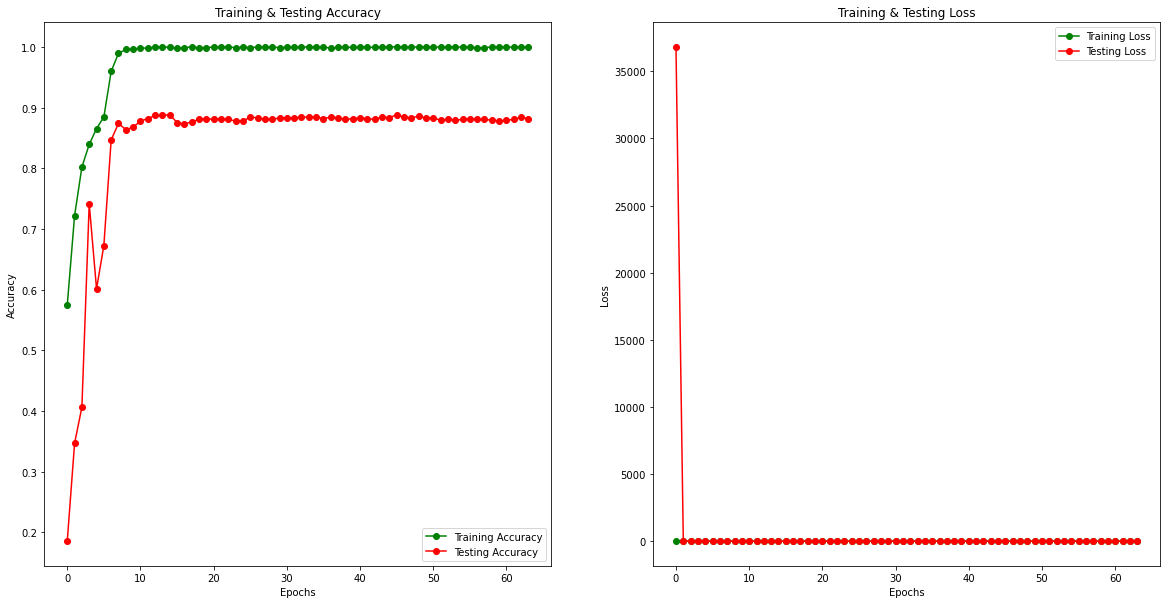

In [13]:
epochs = [i for i in range(EPOCHS)]
fig , ax = plt.subplots(1,2)
train_acc = np.array(history.history['accuracy'])
train_loss = np.array(history.history['loss'])
val_acc = np.array(history.history['val_accuracy'])
val_loss = np.array(history.history['val_loss'])
fig.set_size_inches(20,10)

ax[0].plot(epochs , train_acc , 'go-' , label = 'Training Accuracy')
ax[0].plot(epochs , val_acc , 'ro-' , label = 'Testing Accuracy')
ax[0].set_title('Training & Testing Accuracy')
ax[0].legend()
ax[0].set_xlabel("Epochs")
ax[0].set_ylabel("Accuracy")

ax[1].plot(epochs , train_loss , 'g-o' , label = 'Training Loss')
ax[1].plot(epochs , val_loss , 'r-o' , label = 'Testing Loss')
ax[1].set_title('Training & Testing Loss')
ax[1].legend()
ax[1].set_xlabel("Epochs")
ax[1].set_ylabel("Loss")
plt.show()

In [14]:
#Prediction on test set
print(r'======= PREDICTION ON TEST SET')
predictions = model.predict_classes(x_test)
# print(r'Predict the first 5 elements : ',predictions[:5])
print(r'Done')

======= PREDICTION ON TEST SET
Done


In [15]:
#Inverse transform label binarizer to label
print(r'======= INVERSE TRANSFORM LABEL BINARIZER')
y_test_inv = label_binarizer.inverse_transform(y_test)
print(r'Done')

======= INVERSE TRANSFORM LABEL BINARIZER
Done


In [16]:
print(r'======= SHOW CLASSIFICATION REPORT')
print(classification_report(y_test_inv, predictions, target_names = LABELS))

======= SHOW CLASSIFICATION REPORT
              precision    recall  f1-score   support

    ArtDecor       0.86      0.83      0.84       152
      Hitech       0.86      0.90      0.88       147
   Indochina       0.89      0.93      0.91       176
  Industrial       0.88      0.87      0.87       152
Scandinavian       0.90      0.86      0.88       143

    accuracy                           0.88       770
   macro avg       0.88      0.88      0.88       770
weighted avg       0.88      0.88      0.88       770



======= SHOW CONFUSION MATRIX


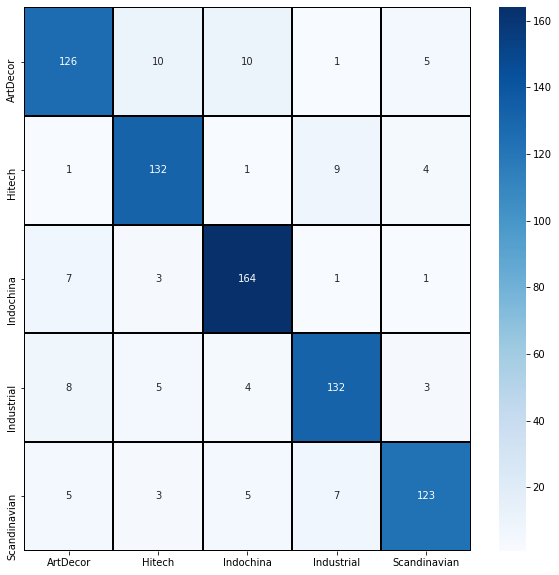

In [17]:
print(r'======= SHOW CONFUSION MATRIX')
cm = confusion_matrix(y_test_inv,predictions)
cm = pd.DataFrame(cm , index = LABELS , columns = LABELS)
plt.figure(figsize = (10,10))
sns.heatmap(cm,cmap= "Blues", linecolor = 'black' , linewidth = 1 , annot = True, fmt='' , xticklabels = LABELS , yticklabels = LABELS)

In [18]:
# now storing some properly as well as misclassified indexes'.
i=0
prop_class=[]
mis_class=[]

for i in range(len(y_test_inv)):
    if(y_test_inv[i] == predictions[i]):
        prop_class.append(i)
    if(len(prop_class)==8):
        break

i=0
for i in range(len(y_test_inv)):
    if(y_test_inv[i] != predictions[i]):
        mis_class.append(i)
    if(len(mis_class)==8):
        break

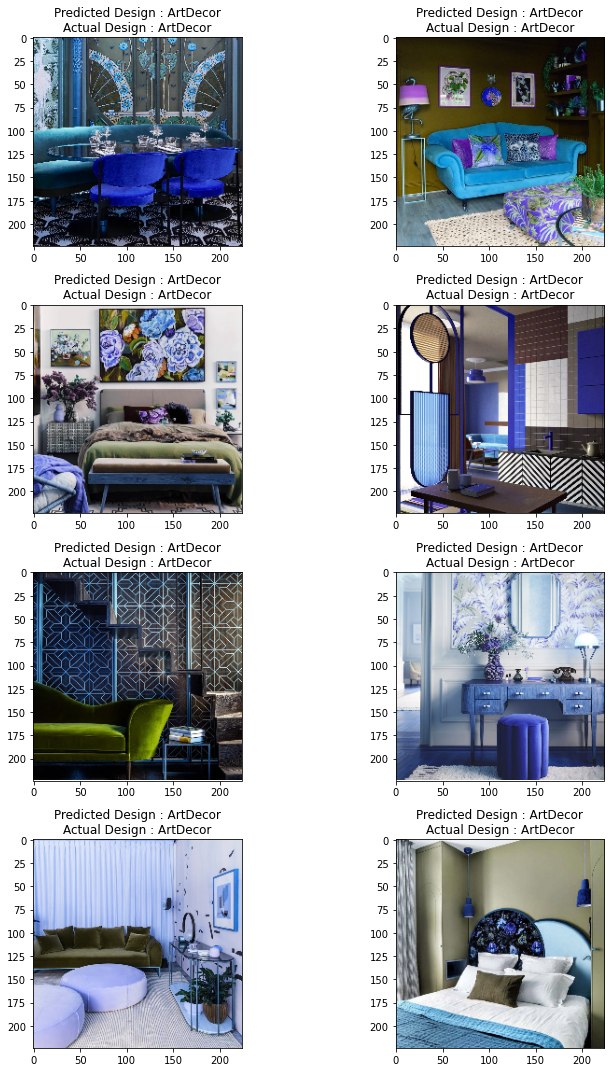

In [19]:
count=0
fig,ax=plt.subplots(len(prop_class)//2,2)
fig.set_size_inches(15,15)
for i in range (len(prop_class)//2):
    for j in range (2):
        ax[i,j].imshow(x_test[prop_class[count]])
        ax[i,j].set_title("Predicted Design : "+ LABELS[predictions[prop_class[count]]] +"\n"+ \
                          "Actual Design : "+ LABELS[int(y_test_inv[prop_class[count]])])
        plt.tight_layout()
        count+=1


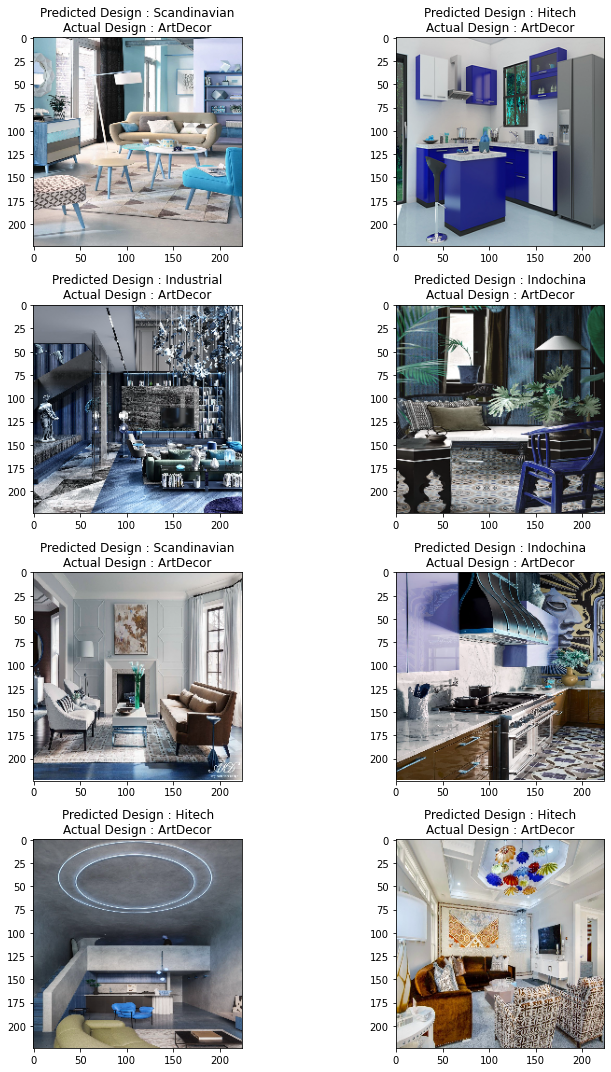

In [20]:
count=0
fig,ax=plt.subplots(len(mis_class)//2,2)
fig.set_size_inches(15,15)
for i in range (len(mis_class)//2):
    for j in range (2):
        ax[i,j].imshow(x_test[mis_class[count]])
        ax[i,j].set_title("Predicted Design : "+ LABELS[predictions[mis_class[count]]]+"\n"+ \
                          "Actual Design : "+ LABELS[int(y_test_inv[mis_class[count]])])
        plt.tight_layout()
        count+=1

In [21]:
model.save_weights(str(IMG_SIZE) + 'x' + str(IMG_SIZE) + '_weights.h5')

In [22]:
model.save('ModelXception.h5')